<a href="https://colab.research.google.com/github/Open-Lemma/options-implied-probability/blob/main/OIPD_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quickstart: OIPD Demo

This notebook will install OIPD, fetch some data and display a probability distribution

<b> We will demonstrate the simplest way to quickly find the future implied probability distribution of a ticker, like Palantir. </b>

This demo consists of 2 sections:
1. Compute the probability distribution of an asset on a specific future date.
2. Compute the future probability over time.

---

In [3]:
# Pip install OIPD
!pip install oipd

## 1. Compute the probability distribution of an asset on a specific future date (using the `ProbCurve` object)

In [4]:
import matplotlib.pyplot as plt

from oipd import MarketInputs, sources, ProbCurve, ProbSurface

### 1.1. I'll show how to use the convenient `sources` object to query and download data.

First, we use the `sources` object to query and download data from yfinance

In [5]:
ticker = "PLTR" # select a ticker

# List available expiries
expiries = sources.list_expiry_dates(ticker) # vendor defaults to "yfinance". Only yfinance is available for now, but we may support other vendors in the future like Alpaca, IBKR, etc.
expiries[:5]

['2026-05-01', '2026-05-08', '2026-05-15', '2026-05-22', '2026-05-29']

Use `sources.fetch_chain()` to download

In [6]:
# Use the first expiry for a single-expiry VolCurve
single_expiry = expiries[4]
chain, snapshot = sources.fetch_chain(ticker, expiries=single_expiry) # this downloads the options chain data, as well as a snapshot of the market conditions at the time you downloaded the data (e.g. stock price, download time, etc.)

print(snapshot.underlying_price) # currently Palantir is $141.18
print(single_expiry) # 2026-05-29

141.18
2026-05-29


`MarketInputs` is a snapshot of market conditions (valuation date, underlying price, risk free rate) that the model uses.

In [7]:
market = MarketInputs(
    valuation_date=snapshot.asof,               # use the snapshot to fill the date and price (this demo is being created on Apr 29, 2026)
    underlying_price=snapshot.underlying_price, # use the snapshot to fill the date and price
    risk_free_rate=0.04,                        # the risk-free rate of return. Use the US Fed or Treasury yields that are closest to the horizon of the expiries
)

### 1.2. Generate the implied-probability distribution using the `ProbCurve` object

Now that all input data is loaded and defined, we can generate the probability. The probability curve is the risk-neutral distribution implied by the market. You can query tail probabilities, quantiles, and moments.

The simplest way to do this is using the `ProbCurve.from_chain()` constructor.

In [8]:
prob = ProbCurve.from_chain(chain, market) # --> returns a `ProbCurve` object. This is a container that holds information about market-implied probabilities.

/usr/local/lib/python3.12/dist-packages/oipd/interface/probability.py:423: DataQualityWarning: VolCurve.fit recorded 2 data-quality warning events; inspect .warning_diagnostics.events for details.
  vol_curve.fit(chain, market, column_mapping=column_mapping)


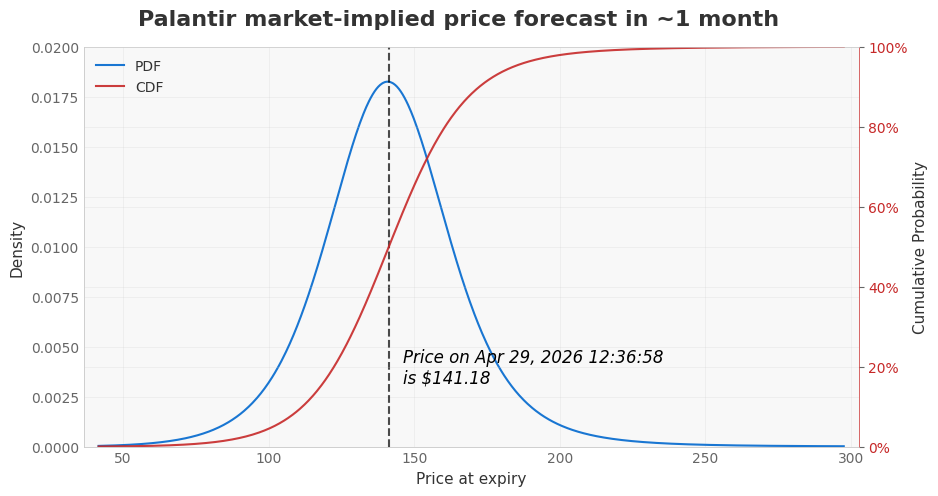

In [9]:
prob.plot(title="Palantir market-implied price forecast in ~1 month")
plt.show()

Now, we can query the result to quantify probabilities and other statistics.

In [10]:
spot = market.underlying_price
print(spot)


prob_below = prob.prob_below(100) # calculates Prob(price at expiry < 100)
prob_above = prob.prob_above(150) # calculates Prob(price at expiry >= 150)
prob_between = prob.prob_between(100, 150)

quantiles = {
    "q10": prob.quantile(0.10),
    "q50": prob.quantile(0.50),
    "q90": prob.quantile(0.90),
}

moments = {
    "mean": prob.mean(),
    "variance": prob.variance(),
    "skew": prob.skew(),
    "kurtosis": prob.kurtosis(),
}

{
    "prob_below": prob_below,
    "prob_above": prob_above,
    "prob_between": prob_between,
    **quantiles,
    **moments,
}

141.18


{'prob_below': 0.04463215141783017,
 'prob_above': 0.347158945404173,
 'prob_between': 0.6082089031779968,
 'q10': 111.58510366907434,
 'q50': 141.29550778854548,
 'q90': 172.43586467276958,
 'mean': 142.07449571972109,
 'variance': 698.6320792330531,
 'skew': 0.8424005017570849,
 'kurtosis': 7.337366985211169}

---

## 2. Compute the future probability over time (using the `ProbSurface` object)

### 2.1. I'll show how to use the convenient `sources` object to query and download data.

First, we use the `sources` object to query and download data from yfinance

In [11]:
ticker = "PLTR" # select a ticker

# we will download all data for the next 12 months
chain_surface, snapshot_surface = sources.fetch_chain(ticker, horizon='12m')

`MarketInputs` is a snapshot of market conditions (valuation date, underlying price, risk free rate) that the model uses.

In [12]:
surface_market = MarketInputs(
    valuation_date=snapshot_surface.asof,
    risk_free_rate=0.04,
    underlying_price=snapshot_surface.underlying_price,
)

### 2.2. Generate the implied-probability over time using the `ProbSurface` object

Now that all input data is loaded and defined, we can generate the probability. The probability curve is the risk-neutral distribution implied by the market. You can query tail probabilities, quantiles, and moments.

The simplest way to do this is using the `ProbSurface.from_chain()` method.

<br>

<i> Note the naming convention. Earlier, we used the `ProbCurve` as we were computing a 2d slice for a single date. Now that we are computing probability over time, we are creating a 3d 'surface', so we use `ProbSurface` </i>

In [13]:
surface = ProbSurface.from_chain(chain_surface, surface_market)

/usr/local/lib/python3.12/dist-packages/oipd/interface/probability.py:1183: DataQualityWarning: VolSurface.fit recorded 30 data-quality warning events; inspect .warning_diagnostics.events for details.
  vol_surface.fit(


Plot the probability distribution over time as a fan-chart. Looks like the market expects Gamestop to decline in price.

/usr/local/lib/python3.12/dist-packages/oipd/interface/probability.py:1425: WorkflowWarning: ProbSurface.plot_fan recorded 1 workflow warning event; inspect .warning_diagnostics.events for details.
  self._record_surface_warning_events(


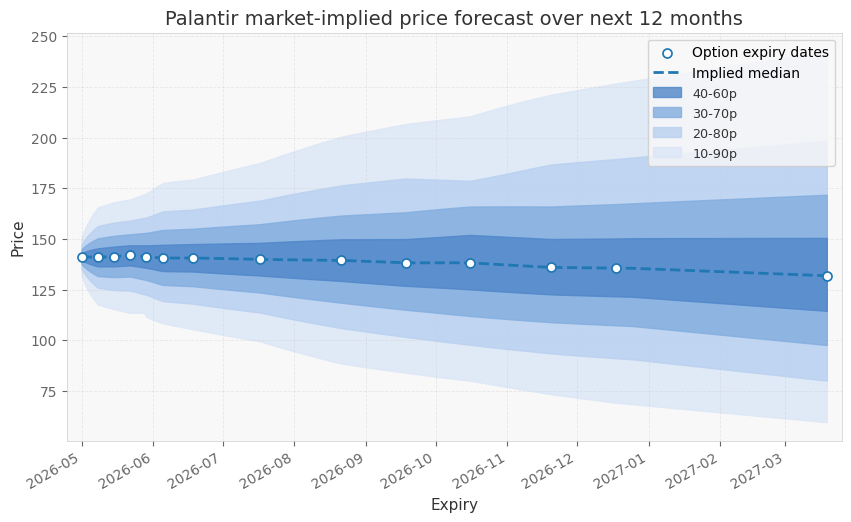

In [15]:
surface.plot_fan(title="Palantir market-implied price forecast over next 12 months")
plt.show()

## Next steps

If you want a deeper tour of all methods (Greeks, quantiles, slicing, and
interpolation), use the AAPL CSV notebooks in `examples/`.